# Fig. 2B--D: 手动填写汇总数值版

本 notebook 不读取任何逐样本 CSV。请在下一单元格直接填写各模型在 `titer`、`strain` 和 `serum` 划分上的 MAE 与 Pearson correlation 的均值和标准差。

每个 seed 内先合并 H1N1 与 H3N2 测试样本计算指标，再对 10 个 seed 求均值和样本标准差（SD）。图中绘制 MAE 柱状图及其 SD 误差线，以及 Pearson 曲线及其 SD 误差线；不绘制显著性检验或 p 值。默认数值为当前结果，可直接覆盖。

In [10]:
# ===== 在此处直接填写数值 =====
# 可调整模型顺序；若要加入 Vaxseer，请把它加入 MODELS，
# 并在每个 split 下补齐 mae_mean / mae_std / pearson_mean / pearson_std 数值。
MODELS = ['FluAgPredictor', 'Nextflu', 'Adaboost']

METRICS = {
    'titer': {
        'FluAgPredictor': {'mae_mean': 0.6838, 'mae_std': 0.0042, 'pearson_mean': 0.8853, 'pearson_std': 0.0008},
        'Nextflu':          {'mae_mean': 0.9421, 'mae_std': 0.0074, 'pearson_mean': 0.7562, 'pearson_std': 0.0051},
        'Adaboost':         {'mae_mean': 0.8948, 'mae_std': 0.0061, 'pearson_mean': 0.7146, 'pearson_std': 0.0029},
    },
    'strain': {
        'FluAgPredictor': {'mae_mean': 0.7056, 'mae_std': 0.0068, 'pearson_mean': 0.8773, 'pearson_std': 0.0026},
        'Nextflu':          {'mae_mean': 0.9461, 'mae_std': 0.0085, 'pearson_mean': 0.7515, 'pearson_std': 0.0067},
        'Adaboost':         {'mae_mean': 0.8914, 'mae_std': 0.0169, 'pearson_mean': 0.7234, 'pearson_std': 0.0165},
    },
    'serum': {
        'FluAgPredictor': {'mae_mean': 0.9168, 'mae_std': 0.1038, 'pearson_mean': 0.7831, 'pearson_std': 0.0680},
        'Nextflu':          {'mae_mean': 1.0493, 'mae_std': 0.1077, 'pearson_mean': 0.7281, 'pearson_std': 0.0744},
        'Adaboost':         {'mae_mean': 0.9407, 'mae_std': 0.1209, 'pearson_mean': 0.7413, 'pearson_std': 0.0681},
    },
}

# None 表示仅显示图、不保存；例如设置为 'Fig2BCD_manual.svg' 可导出 SVG。
OUTPUT_PATH = None


In [11]:
import math
import pandas as pd
import matplotlib.pyplot as plt

COLORS = {
    'FluAgPredictor': '#C5DFF4',
    'Nextflu': '#F4EEAC',
    'Adaboost': '#C9DCC4',
    'Vaxseer': '#F4B6C2',
}
SPLIT_TITLES = {
    'titer': 'divided by titer',
    'strain': 'divided by strain',
    'serum': 'divided by serum',
}

# 将手动填写的数据整理为表格，并在数值缺失时给出明确提示。
records = []
for split in ('titer', 'strain', 'serum'):
    for model in MODELS:
        try:
            values = METRICS[split][model]
            mae_mean = float(values['mae_mean'])
            mae_std = float(values['mae_std'])
            pearson_mean = float(values['pearson_mean'])
            pearson_std = float(values['pearson_std'])
        except (KeyError, TypeError, ValueError) as error:
            raise ValueError(f'请填写 {split} / {model} 的均值和标准差数值。') from error
        if not all(math.isfinite(value) for value in (mae_mean, mae_std, pearson_mean, pearson_std)):
            raise ValueError(f'{split} / {model} 含有非有限数值。')
        if mae_std < 0 or pearson_std < 0:
            raise ValueError(f'{split} / {model} 的标准差不能为负数。')
        records.append({'split': split, 'model': model, 'MAE mean': mae_mean, 'MAE SD': mae_std, 'Pearson mean': pearson_mean, 'Pearson SD': pearson_std})

summary = pd.DataFrame(records)
summary


,split,model,MAE mean,MAE SD,Pearson mean,Pearson SD
0,titer,FluAgPredictor,0.6838,0.0042,0.8853,0.0008
1,titer,Nextflu,0.9421,0.0074,0.7562,0.0051
2,titer,Adaboost,0.8948,0.0061,0.7146,0.0029
3,strain,FluAgPredictor,0.7056,0.0068,0.8773,0.0026
4,strain,Nextflu,0.9461,0.0085,0.7515,0.0067
5,strain,Adaboost,0.8914,0.0169,0.7234,0.0165
6,serum,FluAgPredictor,0.9168,0.1038,0.7831,0.0680
7,serum,Nextflu,1.0493,0.1077,0.7281,0.0744
8,serum,Adaboost,0.9407,0.1209,0.7413,0.0681


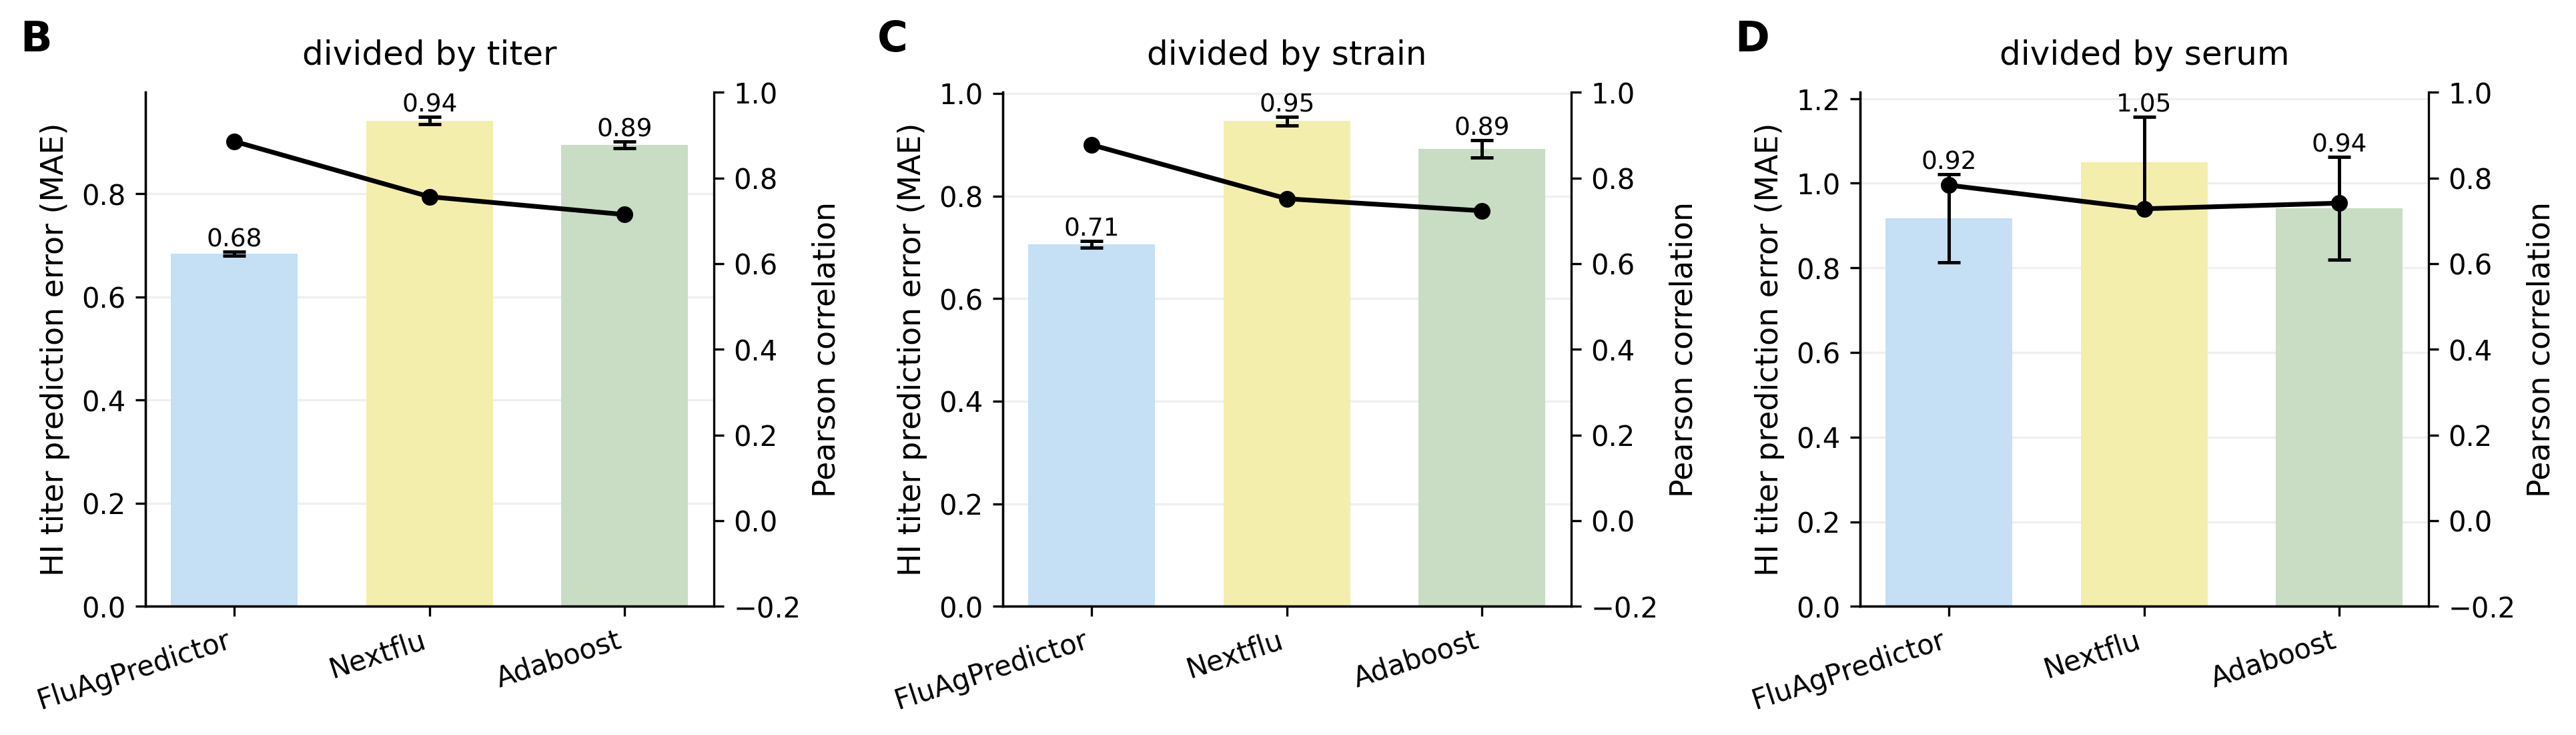

In [13]:
# 绘制 Fig. 2B--D：左轴为 MAE，右轴为 Pearson correlation。
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), dpi=300, sharey=False)
panel_labels = ['B', 'C', 'D']

for ax, split, panel_label in zip(axes, ('titer', 'strain', 'serum'), panel_labels):
    data = summary.loc[summary['split'] == split].set_index('model').loc[MODELS].reset_index()
    x = list(range(len(MODELS)))
    colors = [COLORS.get(model, '#BDBDBD') for model in MODELS]

    bars = ax.bar(x, data['MAE mean'], yerr=data['MAE SD'], color=colors, width=0.65,
                  capsize=4, error_kw={'elinewidth': 1.2, 'capthick': 1.2}, zorder=2)
    ax.set_title(SPLIT_TITLES[split], fontsize=12, pad=10)
    ax.set_ylabel('HI titer prediction error (MAE)', fontsize=11)
    ax.set_xticks(x, MODELS, rotation=18, ha='right', fontsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2, zorder=0)

    for bar, value, std in zip(bars, data['MAE mean'], data['MAE SD']):
        ax.text(bar.get_x() + bar.get_width() / 2, value + std, f'{value:.2f}',
                ha='center', va='bottom', fontsize=9)

    ax2 = ax.twinx()
    ax2.plot(
    x, data['Pearson mean'],
    color='black', marker='o', linewidth=1.7, markersize=5, zorder=3)
    ax2.set_ylabel('Pearson correlation', fontsize=11)
    ax2.set_ylim(-0.2, 1.0)
    ax2.tick_params(axis='y', labelsize=10)
    ax2.spines['top'].set_visible(False)
    ax.text(-0.22, 1.08, panel_label, transform=ax.transAxes, fontsize=15, fontweight='bold')

fig.tight_layout()
if OUTPUT_PATH is not None:
    fig.savefig(OUTPUT_PATH, bbox_inches='tight')
    print(f'Saved figure to: {OUTPUT_PATH}')
plt.show()


In [5]:
# 可选：导出手动填写的汇总数值，便于记录本次作图使用的数据。
# summary.to_csv('Fig2BCD_manual_values.csv', index=False)
summary.style.format({'MAE mean': '{:.4f}', 'MAE SD': '{:.4f}', 'Pearson mean': '{:.4f}', 'Pearson SD': '{:.4f}'})


,split,model,MAE,Pearson
0,titer,FluAgPredictor,0.6838,0.8853
1,titer,Nextflu,0.9421,0.7562
2,titer,Adaboost,0.8948,0.7146
3,strain,FluAgPredictor,0.7057,0.8772
4,strain,Nextflu,0.9461,0.7514
5,strain,Adaboost,0.8915,0.7231
6,serum,FluAgPredictor,0.9314,0.7856
7,serum,Nextflu,1.0397,0.7364
8,serum,Adaboost,0.9446,0.7456
